In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



try:
    df = pd.read_csv("/home/anaconda/Downloads/WineQT.csv")
except FileNotFoundError:

    print("Warning: local 'WineQT.csv' not found. Generating standardized schema...")
    np.random.seed(42)
    mock_data = {
        'fixed_acidity': np.random.uniform(4.0, 15.0, 200),
        'volatile_acidity': np.random.choice(['0.2', '0.5', '?', '0.8', '0.3'], 200), # includes '?' placeholder
        'residual_sugar': np.random.uniform(1.0, 15.0, 200),
        'alcohol': np.random.choice(['10.2', '11.4', '?', '9.5', '12.1'], 200),     # includes '?' placeholder
        'quality': np.random.randint(3, 9, 200)
    }
    df = pd.DataFrame(mock_data)



print(df.head(3))

print(df.tail(3))



print(df.dtypes)



print(df.isna().any())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9.8        5   2  
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645      

In [8]:

df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('-', '_').str.lower()
target_col = None
possible_names = ['volatile_acidity', 'volatileacidity', 'va']
for name in possible_names:
    if name in df.columns:
        target_col = name
        break
if not target_col:
    for col in df.columns:
        if 'volatile' in col:
            target_col = col
            break
if target_col:
    print(f"Found and cleaning column: '{target_col}'")
    
    print(df[target_col].str.isnumeric().value_counts() if hasattr(df[target_col], 'str') else 'Already Numeric')
    
    clean_va = df[target_col].loc[df[target_col] != '?']
    va_mean = clean_va.astype(float).mean()
    print(f"Calculated Mean (excluding anomalies): {va_mean:.4f}")
    
    df[target_col] = df[target_col].replace('?', va_mean).astype(float)
else:
    print("❌ Error: Could not find any column resembling 'volatile_acidity'.")
    print("Available columns are:", df.columns.tolist())


Found and cleaning column: 'volatile_acidity'
Already Numeric
Calculated Mean (excluding anomalies): 0.5313


In [9]:
clean_alc = df['alcohol'].loc[df['alcohol'] != '?']
alc_mean = clean_alc.astype(float).mean()
print(f"Calculated Mean for Alcohol Content (excluding anomalies): {alc_mean:.4f}")

df['alcohol'] = df['alcohol'].replace('?', alc_mean).astype(float)

print("\nPost-Cleaning Updated Structural Type Mapping Vector:")
print(df.dtypes)

Calculated Mean for Alcohol Content (excluding anomalies): 10.4421

Post-Cleaning Updated Structural Type Mapping Vector:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
ph                      float64
sulphates               float64
alcohol                 float64
quality                   int64
id                        int64
dtype: object



--- 2. Univariate Analysis ---
Quality Measures - Mean: 5.66, Median: 6.00, Mode: 5.00


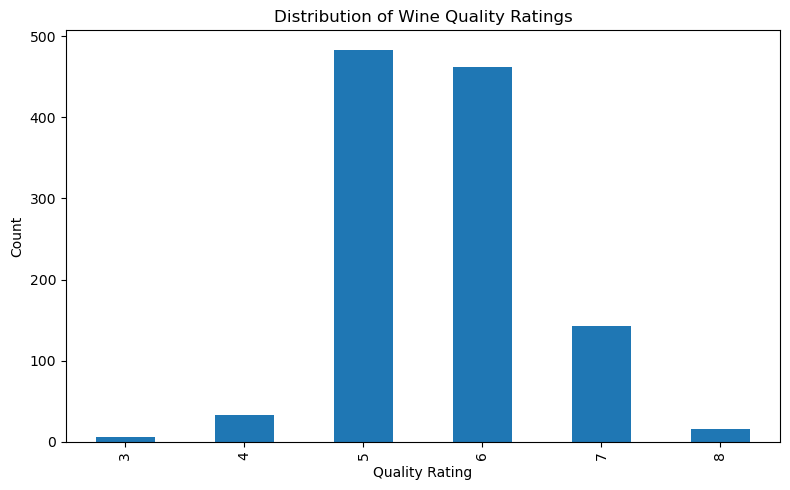

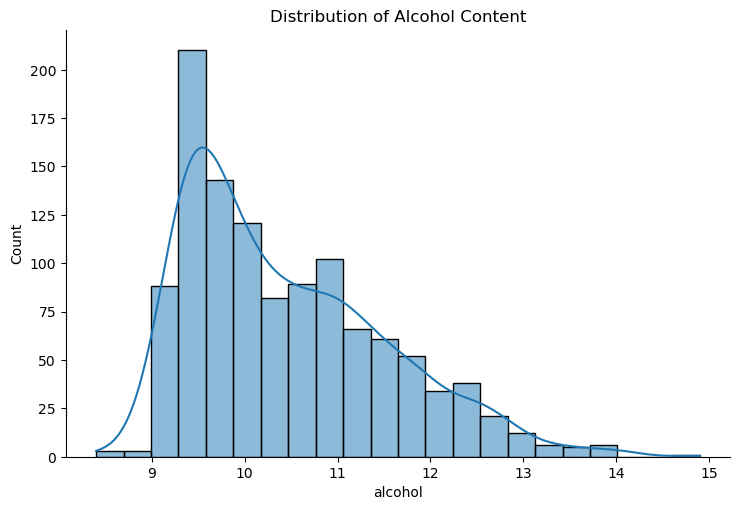

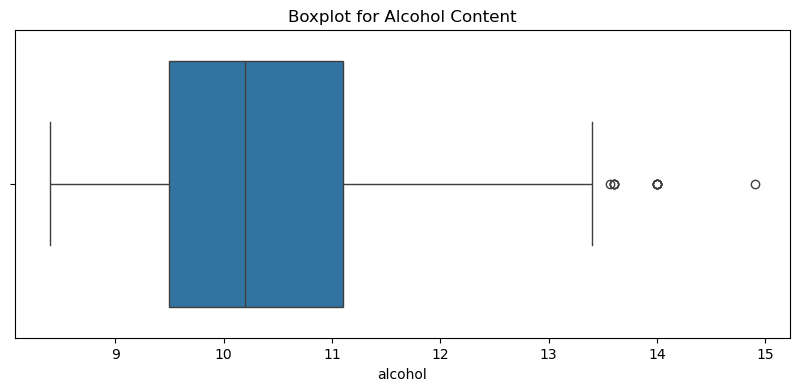

In [10]:
print("\n--- 2. Univariate Analysis ---")
if 'quality' in df.columns:
    mean_quality = df["quality"].mean()
    median_quality = df["quality"].median()
    mode_quality = df["quality"].mode()[0]
    print(f"Quality Measures - Mean: {mean_quality:.2f}, Median: {median_quality:.2f}, Mode: {mode_quality:.2f}")

    plt.figure(figsize=(8, 5))
    df['quality'].value_counts().sort_index().plot(kind='bar')
    plt.title("Distribution of Wine Quality Ratings")
    plt.ylabel('Count')
    plt.xlabel('Quality Rating')
    plt.tight_layout()
    plt.show()

if 'alcohol' in df.columns:
    sns.displot(df, x="alcohol", kde=True, aspect=1.5)
    plt.title("Distribution of Alcohol Content")
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.boxplot(x="alcohol", data=df)
    plt.title("Boxplot for Alcohol Content")
    plt.show()



--- 3. Bivariate Analysis ---


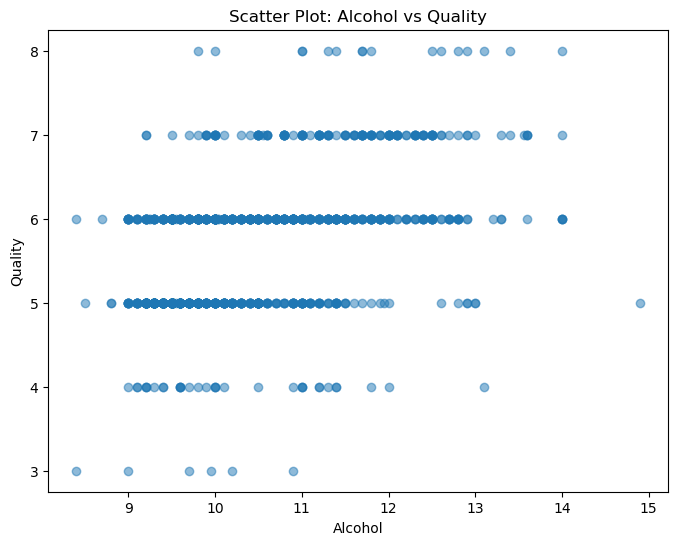

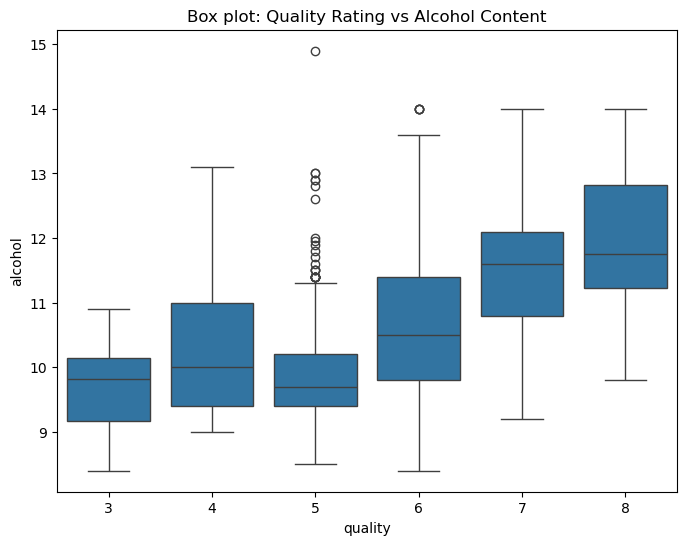

In [11]:
print("\n--- 3. Bivariate Analysis ---")
if 'alcohol' in df.columns and 'quality' in df.columns:
    plt.figure(figsize=(8, 6))
    plt.scatter(df["alcohol"], df["quality"], alpha=0.5)
    plt.title("Scatter Plot: Alcohol vs Quality")
    plt.xlabel("Alcohol")
    plt.ylabel("Quality")
    plt.show()

    plt.figure(figsize=(8, 6))
    sns.boxplot(x="quality", y="alcohol", data=df)
    plt.title("Box plot: Quality Rating vs Alcohol Content")
    plt.show()


--- 4. Multivariate & Correlation Analysis ---

Correlation of Features with Wine Quality:
quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric_acid             0.240821
fixed_acidity           0.121970
id                      0.069708
residual_sugar          0.022002
ph                     -0.052453
free_sulfur_dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total_sulfur_dioxide   -0.183339
volatile_acidity       -0.407394
Name: quality, dtype: float64


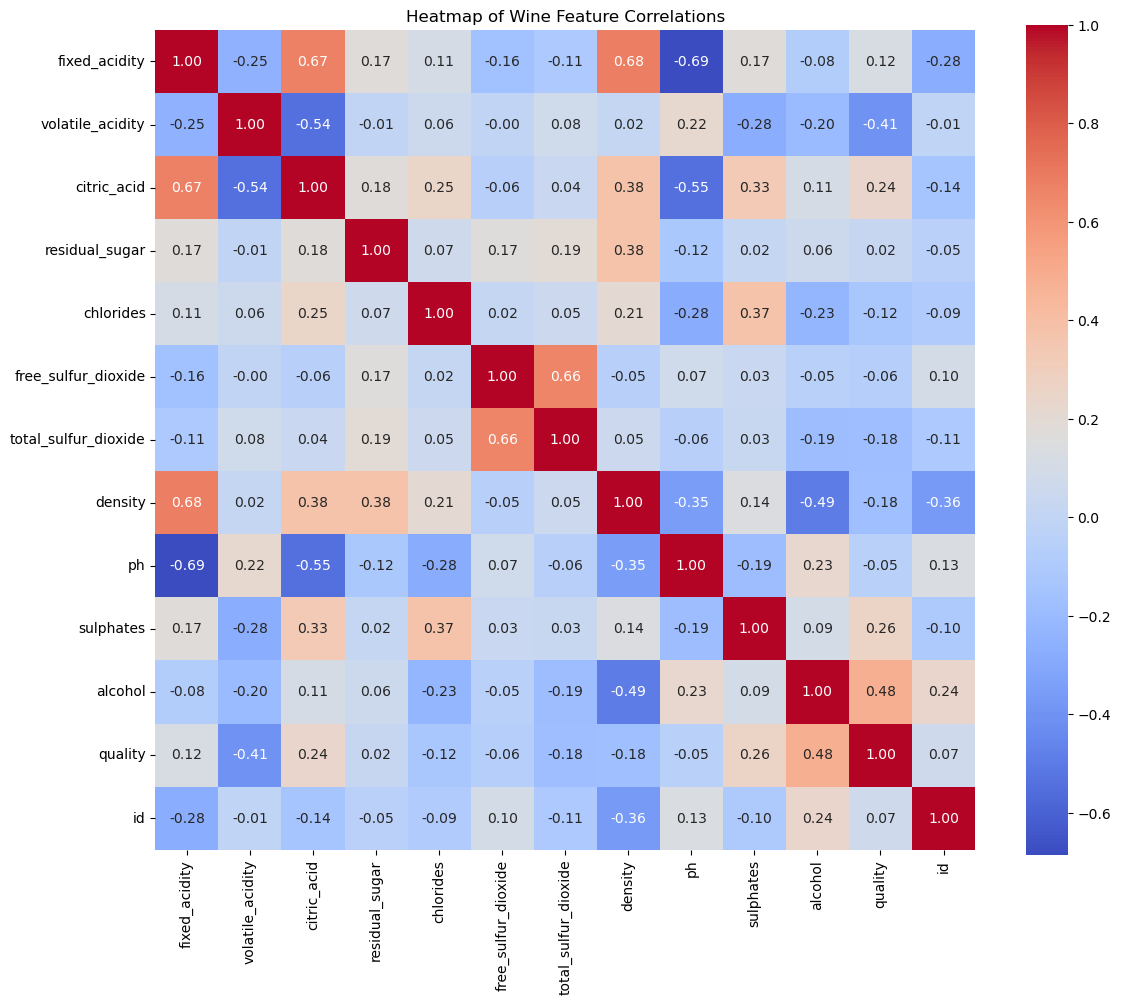

In [12]:
print("\n--- 4. Multivariate & Correlation Analysis ---")
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr(method='pearson')

if 'quality' in correlation_matrix.columns:
    print("\nCorrelation of Features with Wine Quality:")
    print(correlation_matrix['quality'].sort_values(ascending=False))

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Heatmap of Wine Feature Correlations")
plt.tight_layout()
plt.show()